In [1]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
# load dataset

iris = load_iris(as_frame=True)

df = iris.frame

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
df.shape

(150, 5)

In [4]:
df.info

<bound method DataFrame.info of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8

In [5]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
df = df.drop_duplicates()

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# separate target and features

X = df.drop("target", axis=1)
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (149, 4)
y shape: (149,)


In [10]:
# Train - test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (119, 4)
Testing data: (30, 4)


In [11]:
print("Target classes:", iris.target_names)
print("Unique target values:", y.unique())

Target classes: ['setosa' 'versicolor' 'virginica']
Unique target values: [0 1 2]


In [12]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# check
print(X_train_scaled[:5])

[[-1.50158712  0.7690314  -1.33909259 -1.17973677]
 [ 0.63982407 -0.58674247  1.04183404  1.1863645 ]
 [-0.19294695 -0.13481785  0.24819183  0.00331387]
 [-0.90675068  1.67288064 -1.05564894 -1.0482867 ]
 [-1.26365254  0.09114446 -1.22571513 -1.31118684]]


In [14]:
from tensorflow.keras.utils import to_categorical

y_train_encoded = to_categorical(y_train, num_classes=3)
y_test_encoded = to_categorical(y_test, num_classes=3)

In [15]:
# Buid model

model = Sequential([
    
    # Hidden Layer 1
    Dense(10, activation="relu", input_shape=(4,)),
    
    # Hidden Layer 2
    Dense(8, activation="relu"),
    
    # Output Layer
    Dense(3, activation="softmax")
])

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              50 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │              88 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 165 (660.00 B)

 Trainable params: 165 (660.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
# compile model

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:

# Train the ANN Model

history = model.fit(
    X_train_scaled,
    y_train_encoded,
    epochs=50,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.1895 - loss: 1.1418 - val_accuracy: 0.2917 - val_loss: 1.1152
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3474 - loss: 1.0751 - val_accuracy: 0.4167 - val_loss: 1.0476
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4526 - loss: 1.0162 - val_accuracy: 0.4167 - val_loss: 0.9889
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4526 - loss: 0.9645 - val_accuracy: 0.4167 - val_loss: 0.9370
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4842 - loss: 0.9177 - val_accuracy: 0.3750 - val_loss: 0.8920
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5158 - loss: 0.8782 - val_accuracy: 0.4167 - val_loss: 0.8497
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5474 - loss: 0.8402 - val_accuracy: 0.4583 - val_loss: 0.8123
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5368 - loss: 0.8063 - val_accuracy: 0.5000 - v

In [19]:
# Evaluate the ANN Model

test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test_encoded
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.8667 - loss: 0.2975
Test Loss: 0.2974739372730255
Test Accuracy: 0.8666666746139526


In [20]:
# predict
y_pred_prob = model.predict(X_test_scaled)

y_pred = y_pred_prob.argmax(axis=1)

print(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
[1 1 2 0 2 1 1 0 2 2 0 0 0 1 2 0 2 0 2 0 1 1 0 0 1 2 2 2 2 2]


In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  7  3]
 [ 0  1  9]]


In [22]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.88      0.70      0.78        10
   virginica       0.75      0.90      0.82        10

    accuracy                           0.87        30
   macro avg       0.88      0.87      0.87        30
weighted avg       0.88      0.87      0.87        30



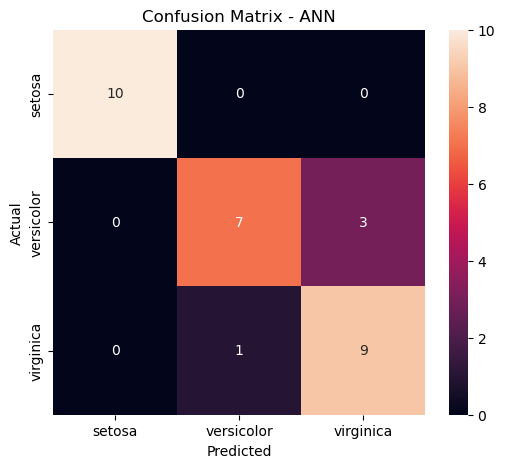

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ANN")
plt.show()

In [26]:
# Unseen data
new_data = np.array([[5.1, 3.5, 1.4, 0.2]])

# Scale using the existing scaler
new_data_scaled = scaler.transform(new_data)

# Prediction
prediction_prob = model.predict(new_data_scaled)

prediction = prediction_prob.argmax(axis=1)[0]

# Class name
species = iris.target_names[prediction]

print("Predicted Species:", species)
print("Probabilities:", prediction_prob[0])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
Predicted Species: setosa
Probabilities: [9.9494815e-01 4.4135498e-03 6.3816778e-04]
